In [29]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib, pickle
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

from python import forces, integrators, random_matrix, simulate, densities, plotters, solvers
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters); importlib.reload(solvers);

---

Re-implementing the HMC but for some $L$ leapfrog steps. First, the explicit method (Chafai and Ferre) but $L>1$. Then looking to see if can write MAIMLA as an integrator step.

Code has been changed to reflect notes: $x$ is current state, $y$ is proposed, $p$ is current momentum, $q$ is proposed.


In [7]:
M = 20; N = 100
beta = 2.0; potential_name = "quartic"; 
dt = 1/N; T = 10.0;
total_steps = int(T/dt);

init = random_matrix.init_quartic_eigenvalues(M, N)
hmc_pipe = simulate.make_hmc_pipeline(N, dt, potential_name, beta)
trajectory = simulate.simulate_dbm(init, total_steps, hmc_pipe)

config = {"burn_in": 0, "snapshot_interval": 5, "track_accepts": True}
info = simulate.analyse_trajectory(trajectory, total_steps, **config)

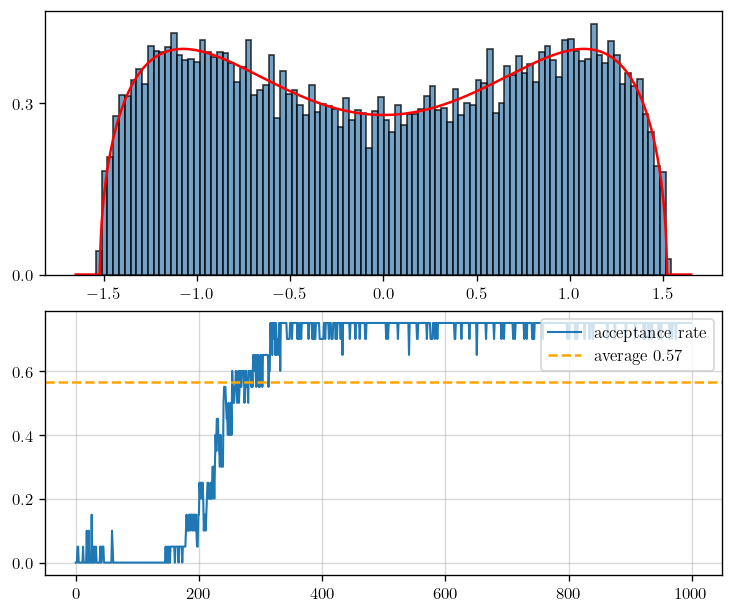

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (6, 5))
plotters.plot_hist(ax1, info["snapshots"], potential_name = "quartic")
plotters.plot_accepts(ax2, info["accepts"])
plt.show()

---
---
---

Side by side comparison running for the same number of steps, with $(\Delta t)_{HMC} = \sqrt{2(\Delta t)_{MALA}}$.

In [45]:
M = 20; N = 100
beta = 2.0; potential_name = "quartic"; 
dt_mala = 1/(4*N) # Tuning to obtain ~30% acceptance.
dt_hmc = np.sqrt(2*dt_mala)
T = 3.0;

total_steps_mala = int(T/dt_mala)
total_steps_hmc = int(T/dt_mala)
L = 1; gamma_N = 1e6

init = random_matrix.init_quartic_eigenvalues(M, N)
mala_pipe = simulate.make_mala_pipeline(N, dt_mala, potential_name, beta)
mala_traj = simulate.simulate_dbm(init, total_steps_mala, mala_pipe)

hmc_pipe = simulate.make_hmc_pipeline(N, dt_hmc, potential_name, beta, L = L, gamma_N = gamma_N)
hmc_traj = simulate.simulate_dbm(init, total_steps_hmc, hmc_pipe)

grid = np.linspace(-2, 2, 1000); F_exact = densities.compute_exact_cdf(N, potential_name, grid)
config_mala = {"burn_in": int(total_steps_mala/2), "snapshot_interval": 5, "track_accepts": True, "track_distance": True,
            "grid": grid, "F_exact": F_exact, "dt": dt_mala}
config_hmc = {"burn_in": int(total_steps_mala/2), "snapshot_interval": 5, "track_accepts": True, "track_distance": True,
            "grid": grid, "F_exact": F_exact, "dt": dt_hmc}
info_mala = simulate.analyse_trajectory(mala_traj, total_steps_mala, **config_mala)
info_hmc = simulate.analyse_trajectory(hmc_traj, total_steps_hmc, **config_hmc)

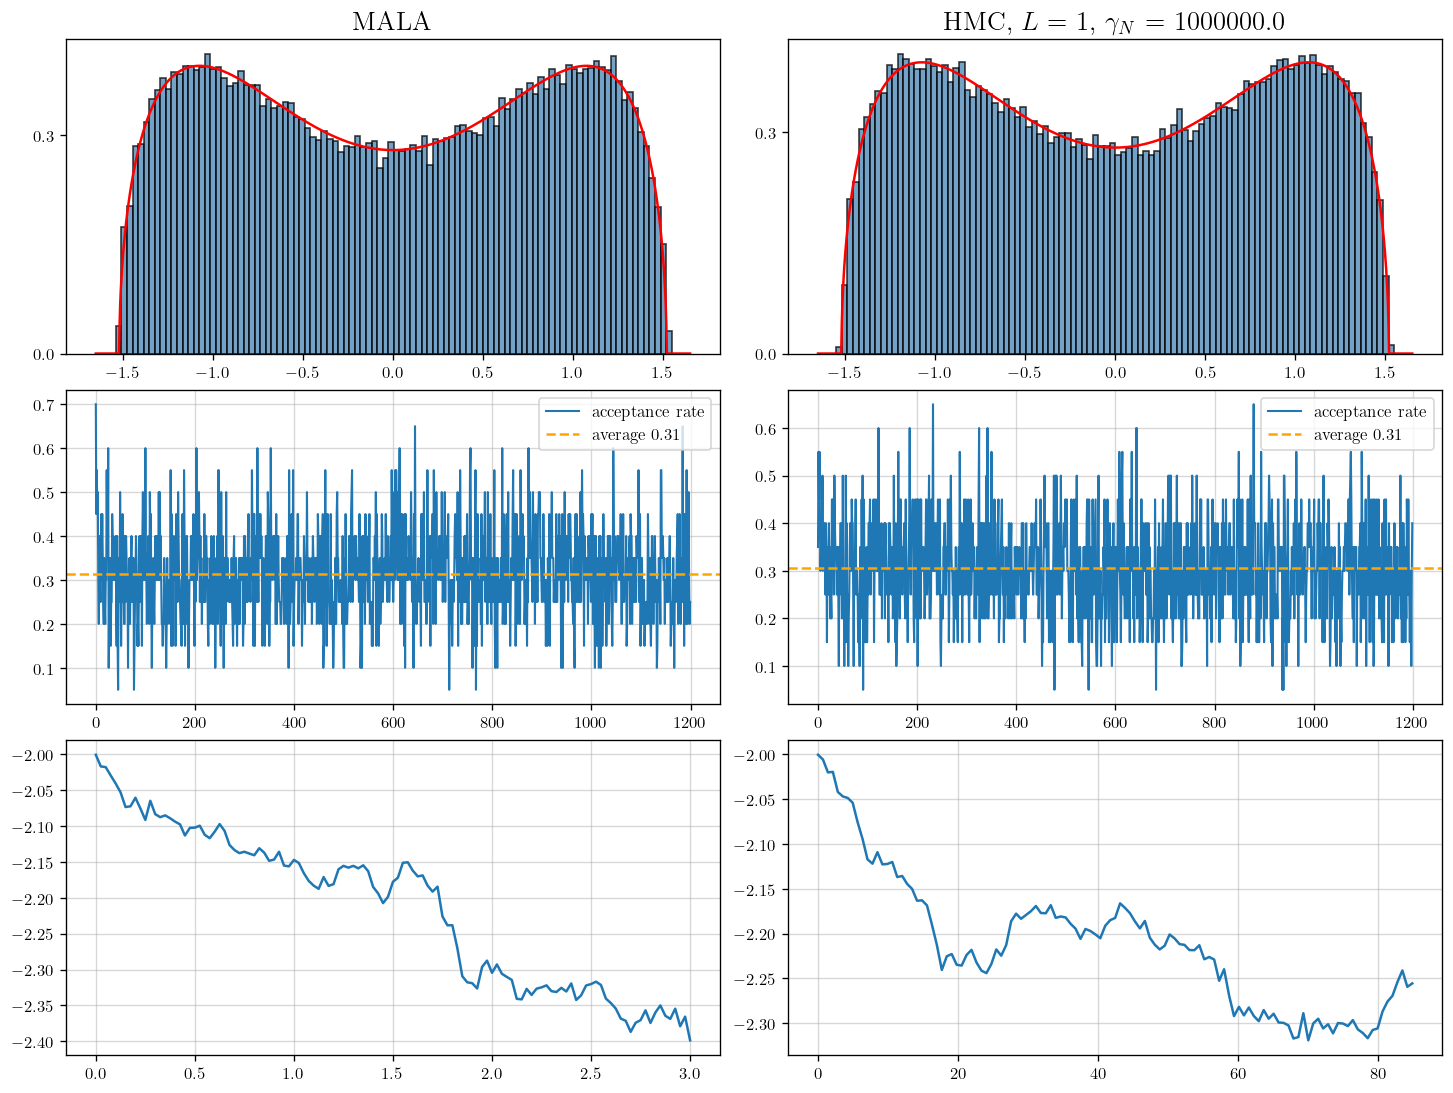

In [46]:
fig, axes = plt.subplots(3, 2, figsize = (12, 9))
ax1, ax2, ax3 = axes[:, 0]

plotters.plot_hist(ax1, info_mala["snapshots"], potential_name = "quartic")
plotters.plot_accepts(ax2, info_mala["accepts"])
plotters.plot_distances(ax3, info_mala)
ax1.set_title("MALA", fontsize = 16, fontweight = "bold")

ax1, ax2, ax3 = axes[:, 1]
plotters.plot_hist(ax1, info_hmc["snapshots"], potential_name = "quartic")
plotters.plot_accepts(ax2, info_hmc["accepts"])
plotters.plot_distances(ax3, info_hmc)
ax1.set_title(rf"HMC, $L$ = {L}, $\gamma_N$ = {gamma_N}", fontsize = 16, fontweight = "bold")

plt.show()

---

In [49]:
M = 20; N = 100
beta = 2.0; potential_name = "quartic"; 
dt_mala = 1/(4*N)
dt_hmc = np.sqrt(2*dt_mala)
T = 3.0;

total_steps_mala = int(T/dt_mala)
total_steps_hmc = int(T/dt_mala)
L = 10; gamma_N = 1.0;

init = random_matrix.init_quartic_eigenvalues(M, N)
mala_pipe = simulate.make_mala_pipeline(N, dt_mala, potential_name, beta)
mala_traj = simulate.simulate_dbm(init, total_steps_mala, mala_pipe)

hmc_pipe = simulate.make_hmc_pipeline(N, dt_hmc, potential_name, beta, L = L, gamma_N = gamma_N)
hmc_traj = simulate.simulate_dbm(init, total_steps_hmc, hmc_pipe)

grid = np.linspace(-2, 2, 1000); F_exact = densities.compute_exact_cdf(N, potential_name, grid)
config_mala = {"burn_in": int(total_steps_mala/2), "snapshot_interval": 5, "track_accepts": True, "track_distance": True,
            "grid": grid, "F_exact": F_exact, "dt": dt_mala}
config_hmc = {"burn_in": int(total_steps_mala/2), "snapshot_interval": 5, "track_accepts": True, "track_distance": True,
            "grid": grid, "F_exact": F_exact, "dt": dt_hmc}
info_mala = simulate.analyse_trajectory(mala_traj, total_steps_mala, **config_mala)
info_hmc = simulate.analyse_trajectory(hmc_traj, total_steps_hmc, **config_hmc)

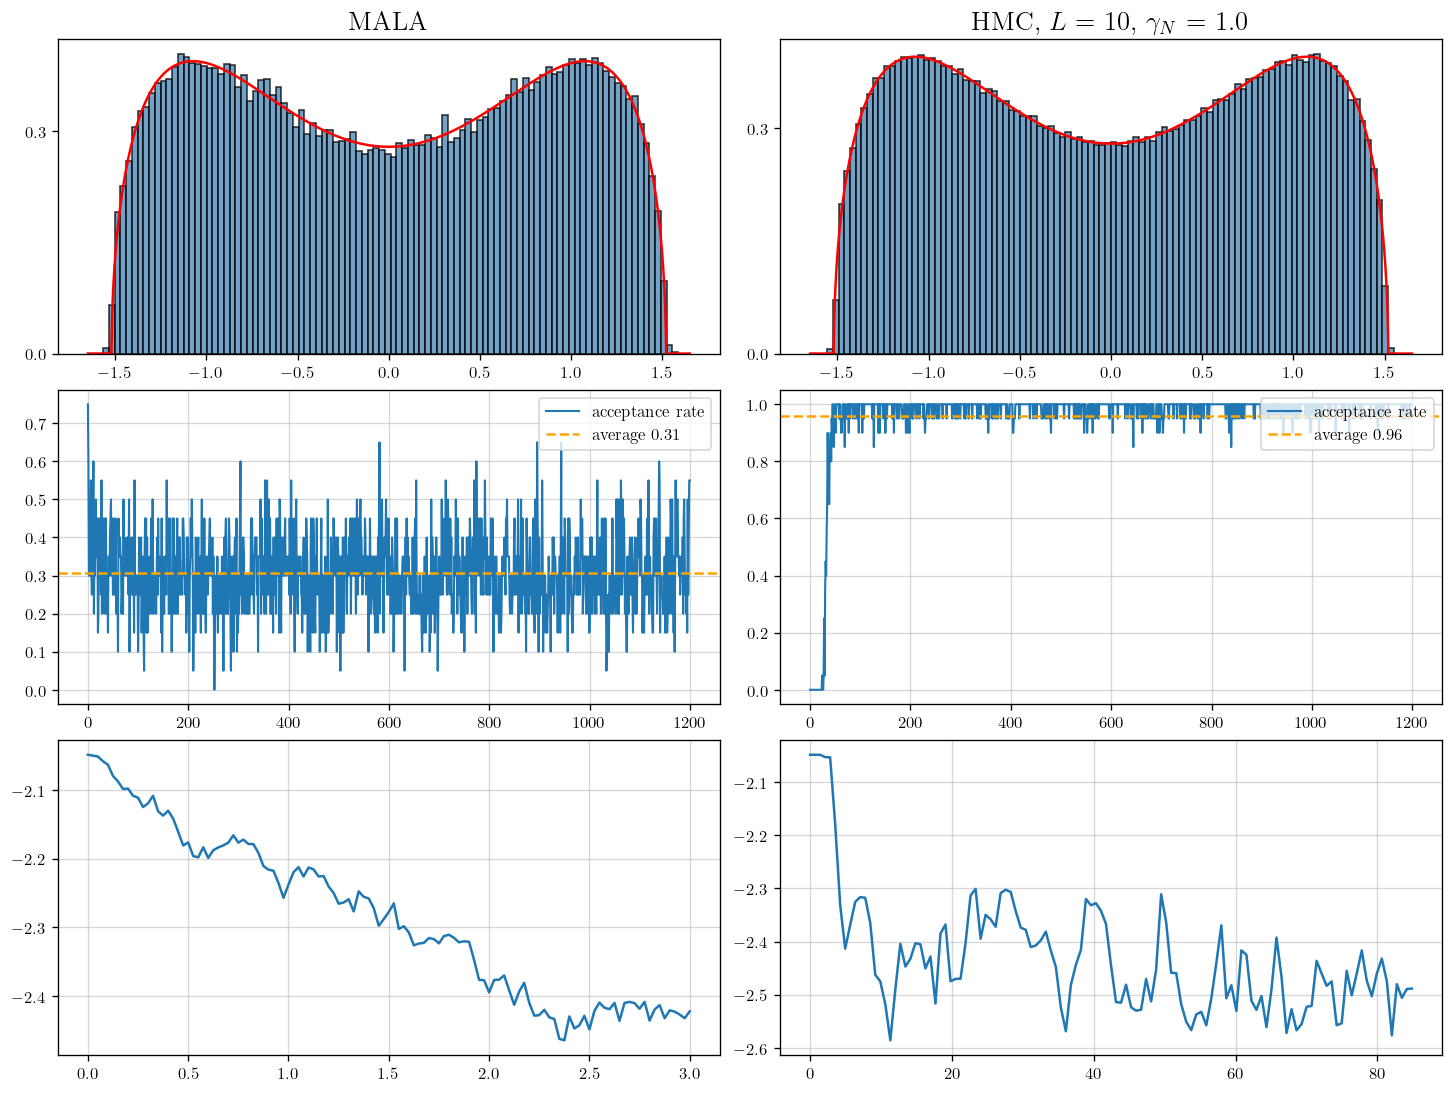

In [50]:
fig, axes = plt.subplots(3, 2, figsize = (12, 9))
ax1, ax2, ax3 = axes[:, 0]

plotters.plot_hist(ax1, info_mala["snapshots"], potential_name = "quartic")
plotters.plot_accepts(ax2, info_mala["accepts"])
plotters.plot_distances(ax3, info_mala)
ax1.set_title("MALA", fontsize = 16, fontweight = "bold")

ax1, ax2, ax3 = axes[:, 1]
plotters.plot_hist(ax1, info_hmc["snapshots"], potential_name = "quartic")
plotters.plot_accepts(ax2, info_hmc["accepts"])
plotters.plot_distances(ax3, info_hmc)
ax1.set_title(rf"HMC, $L$ = {L}, $\gamma_N$ = {gamma_N}", fontsize = 16, fontweight = "bold")

plt.show()